In [ ]:
# ===============================================
# IOI-Proximity Analyse für Param-Sets auf Datei oder Ordner
# inklusive Nullmodell-Statistik und best_peaks
# ===============================================

import pandas as pd
import numpy as np
from pathlib import Path
from tabulate import tabulate

# =============================
# 1) Gaussian-based Proximity-Funktion
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
    top_n_peaks=3
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))

    result = np.zeros_like(x, dtype=float)
    best_peak = np.zeros_like(x, dtype=float)
    best_frac = [(0, 0)] * len(x)  # speichert (k,f) statt nur mu

    for f in range(1, max_freq + 1):
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        weight_f = 1.0 / (f ** weight_exponent)

        for i, xi in enumerate(x):
            k_vals = np.array([int(np.floor(xi*f)), int(np.ceil(xi*f))])
            k_vals = k_vals[k_vals > 0]
            k_vals = k_vals[k_vals <= x_max*f]

            if len(k_vals) == 0:
                continue

            for k in k_vals:
                mu = k / f
                sigma = 1.0 / (sharpness_f * (k ** sharpness_growth) + 1e-9)
                mu_decay = 1.0 / (mu ** decay)
                g = weight_f * mu_decay * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)

                if g > result[i]:
                    result[i] = g
                    best_peak[i] = mu
                    best_frac[i] = (k, f)

    # Normierung
    result /= np.max(result) + 1e-9
    result *= output_max

    # Peaks und "keine Proximity" zählen
    peaks_count = {}
    for val, frac in zip(result, best_frac):
        if val >= threshold and frac != (0, 0):
            k, f = frac
            label = f"{k}/{f}"
        else:
            label = "keine Proximity"

        peaks_count[label] = peaks_count.get(label, 0) + 1

    # Prozente berechnen
    total = sum(peaks_count.values())
    peaks_count = {k: v / total * 100 for k, v in peaks_count.items()}

    # Top-N behalten, "keine Proximity" immer behalten
    sorted_items = sorted(
        [(k, v) for k, v in peaks_count.items() if k != "keine Proximity"],
        key=lambda kv: kv[1],
        reverse=True
    )[:top_n_peaks]

    if "keine Proximity" in peaks_count:
        sorted_items.append(("keine Proximity", peaks_count["keine Proximity"]))

    peaks_count = dict(sorted_items)

    return result, best_peak, peaks_count

# =============================
# 2) Median + Nullmodell-P-Werte
# =============================

def compute_proximity_stats(iois, params, num_null=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(iois)
    if n < 2:
        return {
            "mean_real": np.nan,
            "median_real": np.nan,
            "pval_expon_mean": np.nan,
            "pval_expon_median": np.nan,
            "pval_uniform_mean": np.nan,
            "pval_uniform_median": np.nan,
            "mean_expon": np.nan,
            "median_expon": np.nan,
            "mean_uniform": np.nan,
            "median_uniform": np.nan,
            "peaks_count": {}
        }

    # obere Dreiecksmatrix
    triu_idx = np.triu_indices(n, k=1)
    ratios = np.array([iois[i]/iois[j] if iois[i]>=iois[j] else iois[j]/iois[i]
                       for i,j in zip(*triu_idx)])
    prox, _, peaks_count = proximity_max_freq_gaussian(ratios, **params)

    mean_real = np.mean(prox)
    median_real = np.median(prox)

    # Nullmodell: Exponential
    null_expon_meds, null_expon_means = [], []
    mean_ioi = np.mean(iois)
    for _ in range(num_null):
        sim_iois = rng.exponential(scale=mean_ioi, size=n)
        ratios_sim = np.array([max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                               for i, j in zip(*triu_idx)])
        prox_sim, _, _ = proximity_max_freq_gaussian(ratios_sim, **params)
        null_expon_meds.append(np.median(prox_sim))
        null_expon_means.append(np.mean(prox_sim))

    median_expon = np.median(null_expon_meds)
    mean_expon = np.mean(null_expon_means)
    pval_expon_median = (np.sum(np.array(null_expon_meds) >= median_real) + 1) / (num_null + 1)
    pval_expon_mean = (np.sum(np.array(null_expon_means) >= mean_real) + 1) / (num_null + 1)

    # Nullmodell: Uniform
    null_uniform_meds, null_uniform_means = [], []
    max_ioi = np.max(iois)
    for _ in range(num_null):
        sim_iois = rng.uniform(0.01, max_ioi, size=n)
        ratios_sim = np.array([max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                               for i, j in zip(*triu_idx)])
        prox_sim, _, _ = proximity_max_freq_gaussian(ratios_sim, **params)
        null_uniform_meds.append(np.median(prox_sim))
        null_uniform_means.append(np.mean(prox_sim))

    median_uniform = np.median(null_uniform_meds)
    mean_uniform = np.mean(null_uniform_means)
    pval_uniform_median = (np.sum(np.array(null_uniform_meds) >= median_real) + 1) / (num_null + 1)
    pval_uniform_mean = (np.sum(np.array(null_uniform_means) >= mean_real) + 1) / (num_null + 1)

    return {
        "mean_real": mean_real,
        "median_real": median_real,
        "pval_expon_mean": pval_expon_mean,
        "pval_expon_median": pval_expon_median,
        "pval_uniform_mean": pval_uniform_mean,
        "pval_uniform_median": pval_uniform_median,
        "mean_expon": mean_expon,
        "median_expon": median_expon,
        "mean_uniform": mean_uniform,
        "median_uniform": median_uniform,
        "peaks_count": peaks_count
    }

# =============================
# 3) Datei / Ordner Analyse
# =============================

def analyze_sequences_with_stats(path, param_sets, param_descriptions, num_null=1000):
    path = Path(path)
    results = []

    if path.is_file():
        # Einzelne Sequenz
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        level = "sequence"
        data_name = path.name

        for idx, (params, desc) in enumerate(zip(param_sets, param_descriptions), start=1):
            stats = compute_proximity_stats(iois, params, num_null=num_null)

            results.append({
                "param_set": f"Set_{idx}",
                "description": desc,
                "data": data_name,
                "level": level,
                **{k: v for k, v in stats.items() if k != "peaks_count"},
                "best_peaks": "\n".join([f"{label} : {v:.0f}%" for label, v in stats["peaks_count"].items()])
            })

    elif path.is_dir():
        # Gesamtes Dataset (Ordner mit Sequenzen)
        csv_files = list(path.glob("*.csv"))
        level = "dataset"
        data_name = path.name

        for idx, (params, desc) in enumerate(zip(param_sets, param_descriptions), start=1):
            mean_reals, median_reals = [], []
            pvals_expon_mean, pvals_expon_median = [], []
            pvals_uniform_mean, pvals_uniform_median = [], []
            mean_expons, median_expons = [], []
            mean_uniforms, median_uniforms = [], []
            best_peaks_list = []

            for file in csv_files:
                df = pd.read_csv(file)
                iois = df["IOI"].dropna().values
                stats = compute_proximity_stats(iois, params, num_null=num_null)

                mean_reals.append(stats["mean_real"])
                median_reals.append(stats["median_real"])
                pvals_expon_mean.append(stats["pval_expon_mean"])
                pvals_expon_median.append(stats["pval_expon_median"])
                pvals_uniform_mean.append(stats["pval_uniform_mean"])
                pvals_uniform_median.append(stats["pval_uniform_median"])
                mean_expons.append(stats["mean_expon"])
                median_expons.append(stats["median_expon"])
                mean_uniforms.append(stats["mean_uniform"])
                median_uniforms.append(stats["median_uniform"])
                best_peaks_list.append(stats["peaks_count"])

            # Peaks über alle Sequenzen aggregieren
            merged_peaks = {}
            for d in best_peaks_list:
                for k, v in d.items():
                    merged_peaks[k] = merged_peaks.get(k, 0) + v
            total = sum(merged_peaks.values())
            if total > 0:
                merged_peaks = {k: v / total * 100 for k, v in merged_peaks.items()}

            results.append({
                "param_set": f"Set_{idx}",
                "description": desc,
                "data": data_name,
                "level": level,
                "mean_real": np.mean(mean_reals),
                "median_real": np.median(median_reals),
                "pval_expon_mean": np.mean(pvals_expon_mean),
                "pval_expon_median": np.mean(pvals_expon_median),
                "pval_uniform_mean": np.mean(pvals_uniform_mean),
                "pval_uniform_median": np.mean(pvals_uniform_median),
                "mean_expon": np.mean(mean_expons),
                "median_expon": np.median(median_expons),
                "mean_uniform": np.mean(mean_uniforms),
                "median_uniform": np.median(median_uniforms),
                "best_peaks": "\n".join([f"{label} : {v:.0f}%" for label, v in merged_peaks.items()])
            })

    else:
        raise ValueError(f"Path {path} is neither file nor folder!")

    return pd.DataFrame(results)

# =============================
# 4) Param-Sets + Beschreibungen
# =============================

param_sets = [
    dict(sharpness_base=6.0, sharpness_growth=0, decay=0,
         max_freq=1, x_max=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=0, decay=0,
         max_freq=1, x_max=10, weight_exponent=0, freq_sharpness_exp=0,
         output_max=1.0),

    dict(sharpness_base=14.0, sharpness_growth=0, decay=0.1,
         max_freq=2, x_max=10, weight_exponent=0, freq_sharpness_exp=0,
         output_max=1.0),

    dict(sharpness_base=8.0, sharpness_growth=0.5, decay=0.2,
         max_freq=3, x_max=10, weight_exponent=0.5, freq_sharpness_exp=1.0,
         output_max=1.0)
]

param_descriptions = [
    "isochrony only",
    "simple heterochrony",
    "complex heterochrony, 2nd harmonic, punished high ratios",
    "high complexity, multiple harmonics, mild decay"
]

# =============================
# 5) Ausgabe & Tabelle
# =============================
def print_table(df, title=None, floatfmt=".4f"):
    if title:
        print(f"\n{title}\n" + "="*len(title))
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=floatfmt))

def show_results(path, name, num_null=10):
    df = analyze_sequences_with_stats(path, param_sets, param_descriptions, num_null=num_null)
    print_table(df, name)
    return df

# Anwendung:
accelerando = show_results("../data/ergebnis-tabellen/accelerando/accelerando.csv", "Accelerando")
heterochrony_1_2 = show_results("../data/ergebnis-tabellen/heterochrony-1-2", "Heterochrony 1-2")
heterochrony_2_3 = show_results("../data/ergebnis-tabellen/heterochrony-2-3", "Heterochrony 2-3")
isochrony_small_jitter = show_results("../data/ergebnis-tabellen/isochrony_small-jitter", "Isochrony small jitter")
isochrony_big_jitter = show_results("../data/ergebnis-tabellen/isochrony_big-jitter", "Isochrony big jitter")
random_exponential = show_results("../data/ergebnis-tabellen/random exponential", "Random exponential")
random_uniform = show_results("../data/ergebnis-tabellen/random uniform", "Random uniform")
#kwa = show_results("../data/Kwa-Sounds Scorpaena spp", "KWa-Sounds Scorpaena spp", num_null=500)
#carollia = show_results("../data/Bat Carollia perspicillata (C_persp)", "Carollia perspicillata", num_null=500)


Accelerando
╒═════════════╤══════════════════════════════════════════════════════════╤═════════════════╤══════════╤═════════════╤═══════════════╤═══════════════════╤═════════════════════╤═════════════════════╤═══════════════════════╤══════════════╤════════════════╤════════════════╤══════════════════╤═══════════════════════╕
│ param_set   │ description                                              │ data            │ level    │   mean_real │   median_real │   pval_expon_mean │   pval_expon_median │   pval_uniform_mean │   pval_uniform_median │   mean_expon │   median_expon │   mean_uniform │   median_uniform │ best_peaks            │
╞═════════════╪══════════════════════════════════════════════════════════╪═════════════════╪══════════╪═════════════╪═══════════════╪═══════════════════╪═════════════════════╪═════════════════════╪═══════════════════════╪══════════════╪════════════════╪════════════════╪══════════════════╪═══════════════════════╡
│ Set_1       │ isochrony only               

KeyboardInterrupt: 

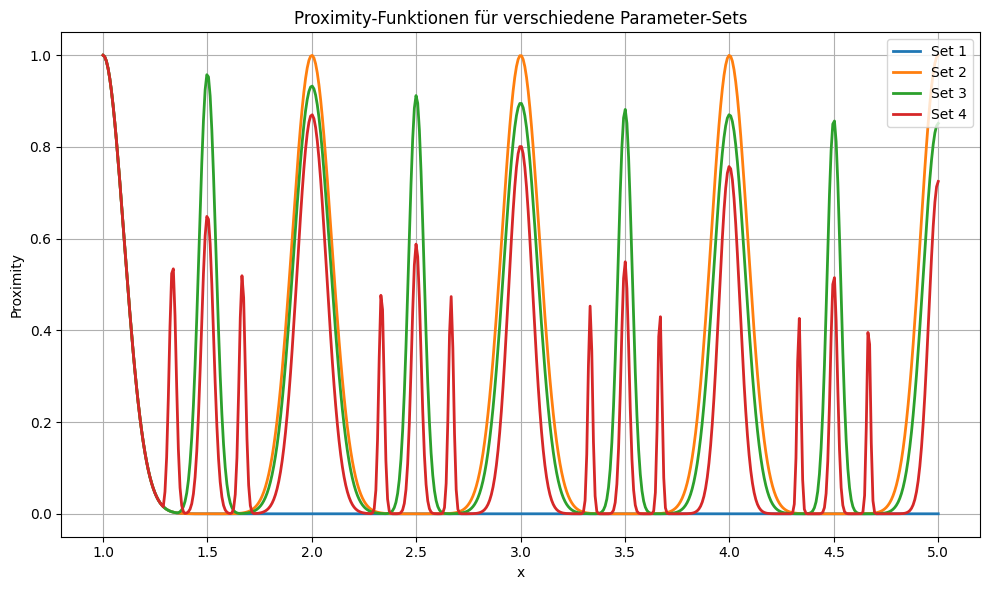

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_proximity_param_sets(x, param_sets, func, labels=None):
    """
    Plotte Proximity-Funktionen für mehrere Parameter-Sets.

    Parameters:
    - x: array-like, Inputwerte
    - param_sets: list of dict, Parameter-Sets für die Funktion
    - func: callable, Proximity-Funktion wie proximity_max_freq_gaussian
            muss (x, **params) -> result, best_peak, peaks_count liefern
    - labels: optional list of str, Beschriftungen der Parameter-Sets
    """
    plt.figure(figsize=(10, 6))

    if labels is None:
        labels = [f"Set {i+1}" for i in range(len(param_sets))]

    for params, label in zip(param_sets, labels):
        result, _, _ = func(x, **params)
        plt.plot(x, result, label=label, linewidth=2)

    plt.xlabel("x")
    plt.ylabel("Proximity")
    plt.title("Proximity-Funktionen für verschiedene Parameter-Sets")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Beispielaufruf

param_sets = [
    dict(sharpness_base=10.0, sharpness_growth=0, decay=0,
         max_freq=1, x_max=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=0.1, decay=0,
         max_freq=1, x_max=10, weight_exponent=0, freq_sharpness_exp=0,
         output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=0.2, decay=0.1,
         max_freq=2, x_max=10, weight_exponent=0, freq_sharpness_exp=1.0,
         output_max=1.0),

    dict(sharpness_base=10.0, sharpness_growth=0.5, decay=0.2,
         max_freq=3, x_max=10, weight_exponent=0.5, freq_sharpness_exp=1.0,
         output_max=1.0)
]

x = np.linspace(1, 5, 500)

plot_proximity_param_sets(x, param_sets, proximity_max_freq_gaussian)



In [13]:
# Alle Ergebnisse in eine Tabelle packen und als CSV speichern
all_results = pd.concat([
    accelerando,
    heterochrony_1_2,
    heterochrony_2_3,
    isochrony_small_jitter,
    isochrony_big_jitter,
    random_exponential,
    random_uniform,
], ignore_index=True)

# Speichern
output_path = "../data/ergebnis-tabellen/gesamt-ergebnisse.csv"
all_results.to_csv(output_path, index=False)

print(f"Alle Ergebnisse gespeichert unter: {output_path}")


Alle Ergebnisse gespeichert unter: ../data/ergebnis-tabellen/gesamt-ergebnisse.csv


In [4]:
# 1:1 peak include-able

# ===============================================
# IOI-Proximity Analyse für Param-Sets auf Datei oder Ordner
# inklusive Nullmodell-Statistik und best_peaks
# ===============================================

import pandas as pd
import numpy as np
from pathlib import Path
from tabulate import tabulate

# =============================
# 1) Gaussian-based Proximity-Funktion
# =============================

def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
    top_n_peaks=3,
    include_identity_peak=True   # <<< steuert, ob 1:1 erlaubt ist
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))

    result = np.zeros_like(x, dtype=float)
    best_peak = np.zeros_like(x, dtype=float)
    best_frac = [(0, 0)] * len(x)  # speichert (k,f) statt nur mu

    for f in range(1, max_freq + 1):
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        weight_f = 1.0 / (f ** weight_exponent)

        for i, xi in enumerate(x):
            k_vals = np.array([int(np.floor(xi*f)), int(np.ceil(xi*f))])
            k_vals = k_vals[k_vals > 0]
            k_vals = k_vals[k_vals <= x_max*f]

            if len(k_vals) == 0:
                continue

            for k in k_vals:
                mu = k / f

                # <<< NEU: 1:1 komplett überspringen, falls nicht erlaubt
                if not include_identity_peak and k == f:
                    continue

                sigma = 1.0 / (sharpness_f * (k ** sharpness_growth) + 1e-9)
                mu_decay = 1.0 / (mu ** decay)
                g = weight_f * mu_decay * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)

                if g > result[i]:
                    result[i] = g
                    best_peak[i] = mu
                    best_frac[i] = (k, f)

    # Normierung
    if np.max(result) > 0:
        result /= np.max(result)
    result *= output_max

    # Peaks und "keine Proximity" zählen
    peaks_count = {}
    for val, frac in zip(result, best_frac):
        if val >= threshold and frac != (0, 0):
            k, f = frac
            label = f"{k}/{f}"
        else:
            label = "keine Proximity"

        peaks_count[label] = peaks_count.get(label, 0) + 1

    # Prozente berechnen
    total = sum(peaks_count.values())
    if total > 0:
        peaks_count = {k: v / total * 100 for k, v in peaks_count.items()}

    # Top-N behalten, "keine Proximity" immer behalten
    sorted_items = sorted(
        [(k, v) for k, v in peaks_count.items() if k != "keine Proximity"],
        key=lambda kv: kv[1],
        reverse=True
    )[:top_n_peaks]

    if "keine Proximity" in peaks_count:
        sorted_items.append(("keine Proximity", peaks_count["keine Proximity"]))

    peaks_count = dict(sorted_items)

    return result, best_peak, peaks_count

# =============================
# 2) Median + Nullmodell-P-Werte
# =============================

def compute_proximity_stats(iois, params, num_null=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(iois)
    if n < 2:
        return {
            "mean_real": np.nan,
            "median_real": np.nan,
            "pval_expon_mean": np.nan,
            "pval_expon_median": np.nan,
            "pval_uniform_mean": np.nan,
            "pval_uniform_median": np.nan,
            "mean_expon": np.nan,
            "median_expon": np.nan,
            "mean_uniform": np.nan,
            "median_uniform": np.nan,
            "peaks_count": {}
        }

    # obere Dreiecksmatrix
    triu_idx = np.triu_indices(n, k=1)
    ratios = np.array([iois[i]/iois[j] if iois[i]>=iois[j] else iois[j]/iois[i]
                       for i,j in zip(*triu_idx)])
    prox, _, peaks_count = proximity_max_freq_gaussian(ratios, **params)

    mean_real = np.mean(prox)
    median_real = np.median(prox)

    # Nullmodell: Exponential
    null_expon_meds, null_expon_means = [], []
    mean_ioi = np.mean(iois)
    for _ in range(num_null):
        sim_iois = rng.exponential(scale=mean_ioi, size=n)
        ratios_sim = np.array([max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                               for i, j in zip(*triu_idx)])
        prox_sim, _, _ = proximity_max_freq_gaussian(ratios_sim, **params)
        null_expon_meds.append(np.median(prox_sim))
        null_expon_means.append(np.mean(prox_sim))

    median_expon = np.median(null_expon_meds)
    mean_expon = np.mean(null_expon_means)
    pval_expon_median = (np.sum(np.array(null_expon_meds) >= median_real) + 1) / (num_null + 1)
    pval_expon_mean = (np.sum(np.array(null_expon_means) >= mean_real) + 1) / (num_null + 1)

    # Nullmodell: Uniform
    null_uniform_meds, null_uniform_means = [], []
    max_ioi = np.max(iois)
    for _ in range(num_null):
        sim_iois = rng.uniform(0.01, max_ioi, size=n)
        ratios_sim = np.array([max(sim_iois[i], sim_iois[j]) / min(sim_iois[i], sim_iois[j])
                               for i, j in zip(*triu_idx)])
        prox_sim, _, _ = proximity_max_freq_gaussian(ratios_sim, **params)
        null_uniform_meds.append(np.median(prox_sim))
        null_uniform_means.append(np.mean(prox_sim))

    median_uniform = np.median(null_uniform_meds)
    mean_uniform = np.mean(null_uniform_means)
    pval_uniform_median = (np.sum(np.array(null_uniform_meds) >= median_real) + 1) / (num_null + 1)
    pval_uniform_mean = (np.sum(np.array(null_uniform_means) >= mean_real) + 1) / (num_null + 1)

    return {
        "mean_real": mean_real,
        "median_real": median_real,
        "pval_expon_mean": pval_expon_mean,
        "pval_expon_median": pval_expon_median,
        "pval_uniform_mean": pval_uniform_mean,
        "pval_uniform_median": pval_uniform_median,
        "mean_expon": mean_expon,
        "median_expon": median_expon,
        "mean_uniform": mean_uniform,
        "median_uniform": median_uniform,
        "peaks_count": peaks_count
    }

# =============================
# 3) Datei / Ordner Analyse
# =============================

def analyze_sequences_with_stats(path, param_sets, param_descriptions, num_null=1000):
    path = Path(path)
    results = []

    if path.is_file():
        # Einzelne Sequenz
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        level = "sequence"
        data_name = path.name

        for idx, (params, desc) in enumerate(zip(param_sets, param_descriptions), start=1):
            stats = compute_proximity_stats(iois, params, num_null=num_null)

            results.append({
                "param_set": f"Set_{idx}",
                "description": desc,
                "data": data_name,
                "level": level,
                **{k: v for k, v in stats.items() if k != "peaks_count"},
                "best_peaks": "\n".join([f"{label} : {v:.0f}%" for label, v in stats["peaks_count"].items()])
            })

    elif path.is_dir():
        # Gesamtes Dataset (Ordner mit Sequenzen)
        csv_files = list(path.glob("*.csv"))
        level = "dataset"
        data_name = path.name

        for idx, (params, desc) in enumerate(zip(param_sets, param_descriptions), start=1):
            mean_reals, median_reals = [], []
            pvals_expon_mean, pvals_expon_median = [], []
            pvals_uniform_mean, pvals_uniform_median = [], []
            mean_expons, median_expons = [], []
            mean_uniforms, median_uniforms = [], []
            best_peaks_list = []

            for file in csv_files:
                df = pd.read_csv(file)
                iois = df["IOI"].dropna().values
                stats = compute_proximity_stats(iois, params, num_null=num_null)

                mean_reals.append(stats["mean_real"])
                median_reals.append(stats["median_real"])
                pvals_expon_mean.append(stats["pval_expon_mean"])
                pvals_expon_median.append(stats["pval_expon_median"])
                pvals_uniform_mean.append(stats["pval_uniform_mean"])
                pvals_uniform_median.append(stats["pval_uniform_median"])
                mean_expons.append(stats["mean_expon"])
                median_expons.append(stats["median_expon"])
                mean_uniforms.append(stats["mean_uniform"])
                median_uniforms.append(stats["median_uniform"])
                best_peaks_list.append(stats["peaks_count"])

            # Peaks über alle Sequenzen aggregieren
            merged_peaks = {}
            for d in best_peaks_list:
                for k, v in d.items():
                    merged_peaks[k] = merged_peaks.get(k, 0) + v
            total = sum(merged_peaks.values())
            if total > 0:
                merged_peaks = {k: v / total * 100 for k, v in merged_peaks.items()}

            results.append({
                "param_set": f"Set_{idx}",
                "description": desc,
                "data": data_name,
                "level": level,
                "mean_real": np.mean(mean_reals),
                "median_real": np.median(median_reals),
                "pval_expon_mean": np.mean(pvals_expon_mean),
                "pval_expon_median": np.mean(pvals_expon_median),
                "pval_uniform_mean": np.mean(pvals_uniform_mean),
                "pval_uniform_median": np.mean(pvals_uniform_median),
                "mean_expon": np.mean(mean_expons),
                "median_expon": np.median(median_expons),
                "mean_uniform": np.mean(mean_uniforms),
                "median_uniform": np.median(median_uniforms),
                "best_peaks": "\n".join([f"{label} : {v:.0f}%" for label, v in merged_peaks.items()])
            })

    else:
        raise ValueError(f"Path {path} is neither file nor folder!")

    return pd.DataFrame(results)

# =============================
# 4) Param-Sets + Beschreibungen
# =============================

param_sets = [
    dict(sharpness_base=6.0, sharpness_growth=0, decay=0,
         max_freq=1, x_max=1, weight_exponent=1.0, freq_sharpness_exp=1.0,
         output_max=1.0, include_identity_peak=True),   # Set 1 inkl.

    dict(sharpness_base=10.0, sharpness_growth=0, decay=0,
         max_freq=1, x_max=10, weight_exponent=0, freq_sharpness_exp=0,
         output_max=1.0, include_identity_peak=False),  # Set 2 ohne

    dict(sharpness_base=14.0, sharpness_growth=0, decay=0.1,
         max_freq=2, x_max=10, weight_exponent=0, freq_sharpness_exp=0,
         output_max=1.0, include_identity_peak=False),  # Set 3 ohne

    dict(sharpness_base=8.0, sharpness_growth=0.5, decay=0.2,
         max_freq=3, x_max=10, weight_exponent=0.5, freq_sharpness_exp=1.0,
         output_max=1.0, include_identity_peak=False)   # Set 4 ohne
]

param_descriptions = [
    "isochrony only",
    "simple heterochrony",
    "complex heterochrony, 2nd harmonic, punished high ratios",
    "high complexity, multiple harmonics, mild decay"
]

# =============================
# 5) Ausgabe & Tabelle
# =============================

def print_table(df, title=None, floatfmt=".4f"):
    if title:
        print(f"\n{title}\n" + "="*len(title))
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=floatfmt))

def show_results(path, name, num_null=200):
    df = analyze_sequences_with_stats(path, param_sets, param_descriptions, num_null=num_null)
    print_table(df, name)
    return df

# Anwendung:
accelerando = show_results("../data/ergebnis-tabellen/accelerando/accelerando.csv", "Accelerando")
heterochrony_1_2 = show_results("../data/ergebnis-tabellen/heterochrony-1-2", "Heterochrony 1-2")
heterochrony_2_3 = show_results("../data/ergebnis-tabellen/heterochrony-2-3", "Heterochrony 2-3")
isochrony_small_jitter = show_results("../data/ergebnis-tabellen/isochrony_small-jitter", "Isochrony small jitter")
isochrony_big_jitter = show_results("../data/ergebnis-tabellen/isochrony_big-jitter", "Isochrony big jitter")
random_exponential = show_results("../data/ergebnis-tabellen/random exponential", "Random exponential")
random_uniform = show_results("../data/ergebnis-tabellen/random uniform", "Random uniform")
kwa = show_results("../data/Kwa-Sounds Scorpaena spp", "KWa-Sounds Scorpaena spp")
carollia = show_results("../data/Bat Carollia perspicillata (C_persp)", "Carollia perspicillata")
whale = show_results("../data/Sperm whale Physeter macrocephalus (sw)", "Whale Codas")



Accelerando
╒═════════════╤══════════════════════════════════════════════════════════╤═════════════════╤══════════╤═════════════╤═══════════════╤═══════════════════╤═════════════════════╤═════════════════════╤═══════════════════════╤══════════════╤════════════════╤════════════════╤══════════════════╤═══════════════════════╕
│ param_set   │ description                                              │ data            │ level    │   mean_real │   median_real │   pval_expon_mean │   pval_expon_median │   pval_uniform_mean │   pval_uniform_median │   mean_expon │   median_expon │   mean_uniform │   median_uniform │ best_peaks            │
╞═════════════╪══════════════════════════════════════════════════════════╪═════════════════╪══════════╪═════════════╪═══════════════╪═══════════════════╪═════════════════════╪═════════════════════╪═══════════════════════╪══════════════╪════════════════╪════════════════╪══════════════════╪═══════════════════════╡
│ Set_1       │ isochrony only               

KeyboardInterrupt: 

In [ ]:
# zählt nur wie oft die besten peaks vorkommen, nicht die Werte
# 1:1 peak include-able (aber nicht mehr nötig)
# ===============================================
# IOI-Proximity Analyse: Peak-Signifikanz über Dataset
# ===============================================

import pandas as pd
import numpy as np
from pathlib import Path
from tabulate import tabulate

# =============================
# 1) Gaussian-based Proximity-Funktion
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
    include_identity_peak=True
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))

    result = np.zeros_like(x, dtype=float)
    best_peak = np.zeros_like(x, dtype=float)
    best_frac = [(0, 0)] * len(x)

    for f in range(1, max_freq + 1):
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        weight_f = 1.0 / (f ** weight_exponent)

        for i, xi in enumerate(x):
            k_vals = np.array([int(np.floor(xi*f)), int(np.ceil(xi*f))])
            k_vals = k_vals[k_vals > 0]
            k_vals = k_vals[k_vals <= x_max*f]

            for k in k_vals:
                mu = k / f
                if not include_identity_peak and k == f:
                    continue
                sigma = 1.0 / (sharpness_f * (k ** sharpness_growth) + 1e-9)
                mu_decay = 1.0 / (mu ** decay)
                g = weight_f * mu_decay * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)
                if g > result[i]:
                    result[i] = g
                    best_peak[i] = mu
                    best_frac[i] = (k, f)

    if np.max(result) > 0:
        result /= np.max(result)
    result *= output_max

    return result, best_frac

# =============================
# 2) Compute Peak-wise p-values
# =============================
def compute_peak_significance(iois, params, num_null=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(iois)
    if n < 2:
        return pd.DataFrame(columns=["peak", "mean_real", "mean_null", "pval"])

    triu_idx = np.triu_indices(n, k=1)
    ratios = np.array([max(iois[i], iois[j])/min(iois[i], iois[j])
                       for i,j in zip(*triu_idx)])
    prox_real, best_frac_real = proximity_max_freq_gaussian(ratios, **params)

    # Peaks identifizieren
    peaks = sorted({f"{k}/{f}" for k,f in best_frac_real if (k,f)!=(0,0)})
    threshold = params.get("threshold", 0.01)

    # Nullmodelle vorbereiten
    mean_ioi = np.mean(iois)
    null_prox_list = []
    for _ in range(num_null):
        sim_iois = rng.exponential(scale=mean_ioi, size=n)
        ratios_sim = np.array([max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j])
                               for i,j in zip(*triu_idx)])
        prox_sim, best_frac_sim = proximity_max_freq_gaussian(ratios_sim, **params)
        null_prox_list.append((prox_sim, best_frac_sim))
    
    peak_data = []
    for peak in peaks:
        # reale Werte für diesen Peak, sonst threshold
        peak_vals = np.array([prox_real[i] if f"{k}/{f}"==peak else threshold
                              for i,(k,f) in enumerate(best_frac_real)])
        mean_real = peak_vals.mean()

        # Nullwerte für diesen Peak, jedes Nullmodell
        null_vals_all = []
        for prox_sim, best_frac_sim in null_prox_list:
            vals = np.array([prox_sim[i] if f"{k}/{f}"==peak else threshold
                             for i,(k,f) in enumerate(best_frac_sim)])
            null_vals_all.append(vals.mean())
        mean_null = np.mean(null_vals_all)
        pval = (np.sum(np.array(null_vals_all) >= mean_real)+1)/(num_null+1)

        peak_data.append({"peak": peak, "mean_real": mean_real, "mean_null": mean_null, "pval": pval})

    return pd.DataFrame(peak_data)

# =============================
# 3) Dataset-Analyse
# =============================
def analyze_dataset_peaks(path, params, num_null=1000):
    path = Path(path)
    if path.is_file():
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        return compute_peak_significance(iois, params, num_null=num_null)
    elif path.is_dir():
        csv_files = list(path.glob("*.csv"))
        all_peak_dfs = []
        for file in csv_files:
            df = pd.read_csv(file)
            iois = df["IOI"].dropna().values
            peak_df = compute_peak_significance(iois, params, num_null=num_null)
            peak_df["file"] = file.name
            all_peak_dfs.append(peak_df)
        # Peaks aggregieren: mean pval über alle Dateien
        df_concat = pd.concat(all_peak_dfs, ignore_index=True)
        df_grouped = df_concat.groupby("peak").agg(
            mean_real=("mean_real", "mean"),
            mean_null=("mean_null", "mean"),
            mean_pval=("pval", "mean")
        ).reset_index()
        return df_grouped
    else:
        raise ValueError(f"{path} is neither file nor folder!")

# =============================
# 4) Tabelle ausgeben
# =============================
def print_peak_table(df, title=None):
    if title:
        print(f"\n{title}\n" + "="*len(title))
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=".4f"))

# =============================
# Beispiel-Aufruf
# =============================

default_params = dict(
    sharpness_base=14.0, sharpness_growth=0.0, decay=0.1,
    max_freq=2, x_max=10, weight_exponent=0.0, freq_sharpness_exp=0.0,
    output_max=1.0, include_identity_peak=True
)

def show_results(path, name, num_null=100):
    df = analyze_dataset_peaks(path, default_params, num_null=num_null)
    print_table(df, name)
    return df

# Anwendung:
accelerando = show_results("../data/ergebnis-tabellen/accelerando/accelerando.csv", "Accelerando")
heterochrony_1_2 = show_results("../data/ergebnis-tabellen/heterochrony-1-2", "Heterochrony 1-2")
heterochrony_2_3 = show_results("../data/ergebnis-tabellen/heterochrony-2-3", "Heterochrony 2-3")
isochrony_small_jitter = show_results("../data/ergebnis-tabellen/isochrony_small-jitter", "Isochrony small jitter")
isochrony_big_jitter = show_results("../data/ergebnis-tabellen/isochrony_big-jitter", "Isochrony big jitter")
random_exponential = show_results("../data/ergebnis-tabellen/random exponential", "Random exponential")
random_uniform = show_results("../data/ergebnis-tabellen/random uniform", "Random uniform")
kwa = show_results("../data/Kwa-Sounds Scorpaena spp", "KWa-Sounds Scorpaena spp")
carollia = show_results("../data/Bat Carollia perspicillata (C_persp)", "Carollia perspicillata")
whale = show_results("../data/Sperm whale Physeter macrocephalus (sw)", "Whale Codas")


Accelerando
╒════════╤═════════════╤═════════════╤════════╕
│ peak   │   mean_real │   mean_null │   pval │
╞════════╪═════════════╪═════════════╪════════╡
│ 1/1    │      0.0797 │      0.0521 │ 0.0594 │
├────────┼─────────────┼─────────────┼────────┤
│ 2/1    │      0.0681 │      0.0466 │ 0.0792 │
├────────┼─────────────┼─────────────┼────────┤
│ 3/1    │      0.0300 │      0.0297 │ 0.4653 │
├────────┼─────────────┼─────────────┼────────┤
│ 3/2    │      0.1224 │      0.0640 │ 0.0198 │
├────────┼─────────────┼─────────────┼────────┤
│ 4/1    │      0.0188 │      0.0222 │ 0.6733 │
├────────┼─────────────┼─────────────┼────────┤
│ 5/1    │      0.0147 │      0.0182 │ 0.7030 │
├────────┼─────────────┼─────────────┼────────┤
│ 5/2    │      0.0435 │      0.0366 │ 0.2673 │
├────────┼─────────────┼─────────────┼────────┤
│ 7/2    │      0.0247 │      0.0251 │ 0.4653 │
├────────┼─────────────┼─────────────┼────────┤
│ 9/2    │      0.0133 │      0.0209 │ 0.9109 │
╘════════╧═════════════╧═══

KeyboardInterrupt: 

In [ ]:
# ===============================================
# IOI-Proximity Analyse: Peak-Signifikanz über Dataset/Sequenz
# inkl. expon, uniform, empirisches Nullmodell, vektorisiert
# ===============================================

import pandas as pd
import numpy as np
from pathlib import Path
from tabulate import tabulate

# =============================
# 1) Gaussian-based Proximity-Funktion (Vektorisiert)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))
    N = len(x)
    result = np.zeros(N)
    best_frac = [(0, 0)] * N

    for f in range(1, max_freq + 1):
        k_vals = np.arange(f, x_max * f + 1)
        mu_all = k_vals / f
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        sigma_all = 1.0 / (sharpness_f * (k_vals ** sharpness_growth) + 1e-9)
        weight_f = 1.0 / (f ** weight_exponent)
        mu_decay_all = 1.0 / (mu_all ** decay)

        diff = x[:, None] - mu_all[None, :]
        g = weight_f * mu_decay_all[None, :] * np.exp(-0.5 * (diff / sigma_all[None, :])**2)
        best_idx = np.argmax(g, axis=1)
        best_val = g[np.arange(N), best_idx]
        update_idx = best_val > result
        result[update_idx] = best_val[update_idx]
        for idx in np.where(update_idx)[0]:
            best_frac[idx] = (int(k_vals[best_idx[idx]]), f)

    if result.max() > 0:
        result /= result.max()
    result *= output_max
    result[result < threshold] = threshold
    return result, best_frac

# =============================
# 2) Nullmodelle generieren
# =============================
def build_null_ratios(n, model, rng, iois):
    if model == "expon":
        sim_iois = rng.exponential(scale=np.median(iois), size=n)
    elif model == "uniform":
        sim_iois = rng.uniform(np.min(iois), np.max(iois), size=n)
    elif model == "empirical":
        sim_iois = rng.choice(iois, size=n, replace=True)
    triu_idx = np.triu_indices(n, k=1)
    ratios = np.maximum(sim_iois[:, None], sim_iois[None, :]) / np.minimum(sim_iois[:, None], sim_iois[None, :])
    return ratios[triu_idx]

# =============================
# 3) Peak-Signifikanz für eine Sequenz
# =============================
def compute_peak_significance(iois, params, num_null=200, seed=42, source="", alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(iois)
    if n < 2:
        return pd.DataFrame()
    triu_idx = np.triu_indices(n, k=1)
    ratios_real = np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])
    ratios_real = ratios_real[triu_idx]

    prox_real, best_frac_real = proximity_max_freq_gaussian(ratios_real, **params)
    threshold = params.get("threshold", 0.01)

    peak_labels = [f"{k}/{f}" if (k,f)!=(0,0) else "keine Proximity" for k,f in best_frac_real]
    peaks = sorted(set([p for p in peak_labels if p != "keine Proximity"]))

    peak_real_scores = {peak: np.array([prox_real[i] if peak_labels[i]==peak else threshold
                                        for i in range(len(prox_real))])
                        for peak in peaks}

    null_scores = {model: {peak: [] for peak in peaks} for model in ["expon", "uniform", "empirical"]}

    for model in ["expon", "uniform", "empirical"]:
        for _ in range(num_null):
            ratios_null = build_null_ratios(n, model, rng, iois)
            prox_null, best_frac_null = proximity_max_freq_gaussian(ratios_null, **params)
            peak_labels_null = [f"{k}/{f}" if (k,f)!=(0,0) else "keine Proximity" for k,f in best_frac_null]
            for peak in peaks:
                vals = np.array([prox_null[i] if peak_labels_null[i]==peak else threshold
                                 for i in range(len(prox_null))])
                null_scores[model][peak].append(np.mean(vals))

    results = []
    for peak in peaks:
        peak_data = {"peak": peak}
        sig_models = []
        for model in ["expon", "uniform", "empirical"]:
            pvals = np.array(null_scores[model][peak])
            mean_null = np.mean(pvals)
            pval = (np.sum(pvals >= np.mean(peak_real_scores[peak])) + 1) / (num_null + 1)
            peak_data[f"{model}_mean_null"] = mean_null
            peak_data[f"{model}_pval"] = pval
            if pval < alpha:   # <<<<<<<<<<<< statt fest 0.05
                sig_models.append(model)
        peak_data[f"significance_alpha: {alpha}"] = ", ".join(sig_models) if sig_models else "n.s."

        peak_data["mean_real"] = np.mean(peak_real_scores[peak])
        # Level + Quelle
        peak_data["level"] = "sequence"
        peak_data["source"] = source
        results.append(peak_data)

    df = pd.DataFrame(results).sort_values("mean_real", ascending=False).reset_index(drop=True)
    # Spaltenreihenfolge anpassen: peak | significance_dataset | level | source | Rest
    col_order = ["peak", f"significance_alpha: {alpha}", "level", "source"] + \
        [c for c in df.columns if c not in ["peak", f"significance_alpha: {alpha}", "level", "source"]]
    return df[col_order]

# =============================
# 4) Dataset-Analyse
# =============================
def analyze_dataset_peaks(path, params, num_null=200, alpha=0.05):
    path = Path(path)
    if path.is_file():
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        return compute_peak_significance(iois, params, num_null=num_null, source=path.name, alpha=alpha)
    elif path.is_dir():
        all_peak_dfs = []
        for file in path.glob("*.csv"):
            df = pd.read_csv(file)
            iois = df["IOI"].dropna().values
            peak_df = compute_peak_significance(iois, params, num_null=num_null, source=file.name, alpha=alpha)
            if not peak_df.empty:
                all_peak_dfs.append(peak_df)
        if not all_peak_dfs:
            return pd.DataFrame()

        df_concat = pd.concat(all_peak_dfs, ignore_index=True)

        grouped = df_concat.groupby("peak")
        final_rows = []
        for peak, g in grouped:
            row = {
                "peak": peak,
                f"significance_alpha: {alpha}": ", ".join([model for model in ["expon","uniform","empirical"]
                                                    if np.sum(g[f"{model}_pval"] < alpha) > len(g)/2]),
                "mean_real": g["mean_real"].mean(),
                "expon_mean_null": g["expon_mean_null"].mean(),
                "expon_pval": g["expon_pval"].mean(),
                "uniform_mean_null": g["uniform_mean_null"].mean(),
                "uniform_pval": g["uniform_pval"].mean(),
                "empirical_mean_null": g["empirical_mean_null"].mean(),
                "empirical_pval": g["empirical_pval"].mean(),
                "level": "dataset",
                "source": path.name
            }
            if row[f"significance_alpha: {alpha}"] == "":
                row[f"significance_alpha: {alpha}"] = "n.s."
            final_rows.append(row)

        df = pd.DataFrame(final_rows).sort_values("mean_real", ascending=False)
        # Spaltenreihenfolge: peak | significance_dataset | level | source | Rest
        col_order = ["peak", f"significance_alpha: {alpha}", "level", "source"] + \
            [c for c in df.columns if c not in ["peak", f"significance_alpha: {alpha}", "level", "source"]]

        return df[col_order]
    else:
        raise ValueError(f"{path} is neither file nor folder!")

# =============================
# 5) Tabelle ausgeben
# =============================
def print_peak_table(df, title=None):
    if title:
        print(f"\n{title}\n" + "="*len(title))
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=".4f"))

# =============================
# 6) Beispiel-Aufruf
# =============================
default_params = dict(
    sharpness_base=14.0, sharpness_growth=0.0, decay=0.0,
    max_freq=4, x_max=10, weight_exponent=0.0, freq_sharpness_exp=1.5,
    output_max=1.0, threshold=0.01
)

def show_results(path, name, num_null=100, alpha=0.05):
    df = analyze_dataset_peaks(path, default_params, num_null=num_null, alpha=alpha)
    print_peak_table(df, name)
    return df

# Anwendung:
accelerando = show_results("../data/ergebnis-tabellen/accelerando/accelerando.csv", "Accelerando")
heterochrony_1_2 = show_results("../data/ergebnis-tabellen/heterochrony-1-2", "Heterochrony 1-2")
heterochrony_2_3 = show_results("../data/ergebnis-tabellen/heterochrony-2-3", "Heterochrony 2-3")
isochrony_small_jitter = show_results("../data/ergebnis-tabellen/isochrony_small-jitter", "Isochrony small jitter")
isochrony_big_jitter = show_results("../data/ergebnis-tabellen/isochrony_big-jitter", "Isochrony big jitter")
random_exponential = show_results("../data/ergebnis-tabellen/random exponential", "Random exponential")
random_uniform = show_results("../data/ergebnis-tabellen/random uniform", "Random uniform")
kwa = show_results("../data/Kwa-Sounds Scorpaena spp", "KWa-Sounds Scorpaena spp")
carollia = show_results("../data/Bat Carollia perspicillata (C_persp)", "Carollia perspicillata")
whale = show_results("../data/Sperm whale Physeter macrocephalus (sw)", "Whale Codas", num_null=50)



Accelerando
╒════════╤════════════════════════════╤══════════╤═════════════════╤═══════════════════╤══════════════╤═════════════════════╤════════════════╤═══════════════════════╤══════════════════╤═════════════╕
│ peak   │ significance_alpha: 0.05   │ level    │ source          │   expon_mean_null │   expon_pval │   uniform_mean_null │   uniform_pval │   empirical_mean_null │   empirical_pval │   mean_real │
╞════════╪════════════════════════════╪══════════╪═════════════════╪═══════════════════╪══════════════╪═════════════════════╪════════════════╪═══════════════════════╪══════════════════╪═════════════╡
│ 1/1    │ n.s.                       │ sequence │ accelerando.csv │            0.0517 │       0.0693 │              0.1298 │         1.0000 │                0.1258 │           1.0000 │      0.0765 │
├────────┼────────────────────────────┼──────────┼─────────────────┼───────────────────┼──────────────┼─────────────────────┼────────────────┼───────────────────────┼──────────────────┼──

KeyboardInterrupt: 

In [28]:
# gegenversuch ob mans nicht auch einfach machen könnte, 
# indem man bei jeder ratio einfach den abstand zu den small integer ratios 
# vergleicht mit denen aus dem nullmodell
# ===============================================
# IOI Peak-Analyse: vereinfachte Version ohne Gaussian
# ===============================================

import pandas as pd
import numpy as np
from pathlib import Path
from tabulate import tabulate

# =============================
# 1) Simplified Peak-Scoring
# =============================
def peak_distance_score_unique(ratios, max_freq=3, x_max=10, exp=2):
    """
    Berechnet für jede Ratio den Abstand zu allen möglichen Peaks k/f.
    Gleiche Peak-Werte (z.B. 6/2 und 3/1) werden zusammengefasst.
    """
    peak_dict = {}  # key: unique ratio, value: list of scores per ratio
    peak_labels_dict = {}  # key: unique ratio, value: label (z.B. "3/1")
    
    for f in range(1, max_freq + 1):
        for k in range(f, x_max*f + 1):
            mu = k / f
            mu_round = round(mu, 6)  # rundet, um Duplikate zu vermeiden
            score_vals = 1.0 / (1.0 + np.abs(ratios - mu)**exp)
            
            # wenn Peak schon da, Werte addieren (oder mitteln später)
            if mu_round in peak_dict:
                peak_dict[mu_round].append(score_vals)
            else:
                peak_dict[mu_round] = [score_vals]
                peak_labels_dict[mu_round] = f"{k}/{f}"

    # Alle Scores mitteln, falls mehrere Einträge pro Peak
    scores = []
    labels = []
    for mu_round, score_list in peak_dict.items():
        combined_scores = np.mean(np.vstack(score_list), axis=0)
        scores.append(combined_scores)
        labels.append(peak_labels_dict[mu_round])

    scores = np.array(scores)  # shape: (num_unique_peaks, num_ratios)
    return scores, labels

# =============================
# 2) Nullmodelle generieren
# =============================
def build_null_ratios(n, model, rng, iois):
    if model == "expon":
        sim_iois = rng.exponential(scale=np.median(iois), size=n)
    elif model == "uniform":
        sim_iois = rng.uniform(np.min(iois), np.max(iois), size=n)
    elif model == "empirical":
        sim_iois = rng.choice(iois, size=n, replace=True)
    triu_idx = np.triu_indices(n, k=1)
    ratios = np.maximum(sim_iois[:, None], sim_iois[None, :]) / np.minimum(sim_iois[:, None], sim_iois[None, :])
    return ratios[triu_idx]

# =============================
# 3) Peak-Signifikanz für eine Sequenz
# =============================
def compute_peak_significance_simple(iois, max_freq=3, x_max=10, num_null=200, seed=42):
    rng = np.random.default_rng(seed)
    n = len(iois)
    if n < 2:
        return pd.DataFrame(columns=["peak", "mean_real", "expon_mean_null", "expon_pval",
                                     "uniform_mean_null", "uniform_pval",
                                     "empirical_mean_null", "empirical_pval"])

    # reale Ratios
    triu_idx = np.triu_indices(n, k=1)
    ratios = np.maximum(iois[:, None], iois[None, :]) / np.minimum(iois[:, None], iois[None, :])
    ratios = ratios[triu_idx]

    scores_real, peak_labels = peak_distance_score_unique(ratios, max_freq=max_freq, x_max=x_max)
    # mean_real pro Peak: Mittelwert aller Scores über alle Ratios
    mean_real_vals = scores_real.mean(axis=1)

    results = []
    for i, peak in enumerate(peak_labels):
        mean_real = mean_real_vals[i]

        peak_data = {"peak": peak, "mean_real": mean_real}
        for model in ["expon", "uniform", "empirical"]:
            mean_vals_null = []
            for _ in range(num_null):
                ratios_null = build_null_ratios(n, model, rng, iois)
                scores_null, _ = peak_distance_score_unique(ratios_null, max_freq=max_freq, x_max=x_max)
                mean_vals_null.append(scores_null[i].mean())
            mean_null = np.mean(mean_vals_null)
            pval = (np.sum(np.array(mean_vals_null) >= mean_real) + 1) / (num_null + 1)
            peak_data[f"{model}_mean_null"] = mean_null
            peak_data[f"{model}_pval"] = pval
        results.append(peak_data)

    return pd.DataFrame(results).sort_values("mean_real", ascending=False).reset_index(drop=True)

# =============================
# 4) Dataset-Analyse
# =============================
def analyze_dataset_peaks_simple(path, max_freq=3, x_max=10, num_null=200):
    path = Path(path)
    if path.is_file():
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        return compute_peak_significance_simple(iois, max_freq=max_freq, x_max=x_max, num_null=num_null)
    elif path.is_dir():
        all_peak_dfs = []
        for file in path.glob("*.csv"):
            df = pd.read_csv(file)
            iois = df["IOI"].dropna().values
            peak_df = compute_peak_significance_simple(iois, max_freq=max_freq, x_max=x_max, num_null=num_null)
            if not peak_df.empty:
                peak_df["file"] = file.name
                all_peak_dfs.append(peak_df)
        if not all_peak_dfs:
            return pd.DataFrame()
        df_concat = pd.concat(all_peak_dfs, ignore_index=True)
        df_grouped = df_concat.groupby("peak").agg({
            "mean_real": "mean",
            "expon_mean_null": "mean", "expon_pval": "mean",
            "uniform_mean_null": "mean", "uniform_pval": "mean",
            "empirical_mean_null": "mean", "empirical_pval": "mean"
        }).reset_index()
        return df_grouped.sort_values("mean_real", ascending=False)
    else:
        raise ValueError(f"{path} is neither file nor folder!")

# =============================
# 5) Tabelle ausgeben
# =============================
def print_peak_table(df, title=None):
    if title:
        print(f"\n{title}\n" + "="*len(title))
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=".4f"))

# =============================
# 6) Beispiel-Aufruf
# =============================
def show_results_simple(path, name, max_freq=3, x_max=10, num_null=100):
    df = analyze_dataset_peaks_simple(path, max_freq=max_freq, x_max=x_max, num_null=num_null)
    print_peak_table(df, name)
    return df

# Anwendung:
accelerando = show_results_simple("../data/ergebnis-tabellen/accelerando/accelerando.csv", "Accelerando")
heterochrony_1_2 = show_results_simple("../data/ergebnis-tabellen/heterochrony-1-2", "Heterochrony 1-2")
heterochrony_2_3 = show_results_simple("../data/ergebnis-tabellen/heterochrony-2-3", "Heterochrony 2-3")
isochrony_small_jitter = show_results_simple("../data/ergebnis-tabellen/isochrony_small-jitter", "Isochrony small jitter")
isochrony_big_jitter = show_results_simple("../data/ergebnis-tabellen/isochrony_big-jitter", "Isochrony big jitter")
random_exponential = show_results_simple("../data/ergebnis-tabellen/random exponential", "Random exponential")
random_uniform = show_results_simple("../data/ergebnis-tabellen/random uniform", "Random uniform")
kwa = show_results_simple("../data/Kwa-Sounds Scorpaena spp", "KWa-Sounds Scorpaena spp")
carollia = show_results_simple("../data/Bat Carollia perspicillata (C_persp)", "Carollia perspicillata")
whale = show_results_simple("../data/Sperm whale Physeter macrocephalus (sw)", "Whale Codas")


Accelerando
╒════════╤═════════════╤═══════════════════╤══════════════╤═════════════════════╤════════════════╤═══════════════════════╤══════════════════╕
│ peak   │   mean_real │   expon_mean_null │   expon_pval │   uniform_mean_null │   uniform_pval │   empirical_mean_null │   empirical_pval │
╞════════╪═════════════╪═══════════════════╪══════════════╪═════════════════════╪════════════════╪═══════════════════════╪══════════════════╡
│ 3/2    │      0.7659 │            0.4474 │       0.0099 │              0.7844 │         0.6733 │                0.7638 │           0.4752 │
├────────┼─────────────┼───────────────────┼──────────────┼─────────────────────┼────────────────┼───────────────────────┼──────────────────┤
│ 5/3    │      0.7603 │            0.4482 │       0.0099 │              0.7778 │         0.6535 │                0.7496 │           0.4653 │
├────────┼─────────────┼───────────────────┼──────────────┼─────────────────────┼────────────────┼───────────────────────┼─────────────

KeyboardInterrupt: 